In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
df = pd.read_csv(r"C:\Users\maihuhuzaif\Downloads\Global_Pollution_Analysis.csv")

In [50]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [51]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [53]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [54]:
print("Dulicated:", df.duplicated())


Dulicated: 0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool


In [55]:
df.drop_duplicates()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Latvia,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,Bangladesh,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,Korea,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,Vanuatu,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [56]:
df["Year"].unique()

array([2005, 2001, 2016, 2018, 2008, 2009, 2006, 2007, 2002, 2000, 2014,
       2010, 2013, 2012, 2003, 2004, 2015, 2017, 2019, 2011])

In [57]:
df.select_dtypes(include='number').columns

Index(['Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')

In [58]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [59]:
df.dtypes

Country                                    object
Year                                        int64
Air_Pollution_Index                       float64
Water_Pollution_Index                     float64
Soil_Pollution_Index                      float64
Industrial_Waste (in tons)                float64
Energy_Recovered (in GWh)                 float64
CO2_Emissions (in MT)                     float64
Renewable_Energy (%)                      float64
Plastic_Waste_Produced (in tons)          float64
Energy_Consumption_Per_Capita (in MWh)    float64
Population (in millions)                  float64
GDP_Per_Capita (in USD)                   float64
dtype: object

In [60]:
x = df.drop(columns=["Country" , "Energy_Recovered (in GWh)"])
y = df["Energy_Recovered (in GWh)"]

In [61]:
print(x.shape)
print(y.shape)
print(x.columns)

(200, 11)
(200,)
Index(['Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'CO2_Emissions (in MT)', 'Renewable_Energy (%)',
       'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')


In [62]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split( x , y , test_size=0.2 , random_state=42)

In [63]:
print( x_train.shape ,x_test.shape ,y_train.shape , y_test.shape)

(160, 11) (40, 11) (160,) (40,)


In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler()

In [66]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(x_train_scaled[:2])

[[ 0.6131199  -1.59831704 -1.75337292 -1.2268179  -1.43071461 -0.04247021
   1.14821132 -1.23504587 -1.09699201  0.05999728  1.08083762]
 [ 0.26463257 -0.51100845  0.64819525 -0.97259554 -1.79582416  0.93614813
   0.95003297  0.00513804  0.8858516   1.33301341 -0.35723877]]


In [67]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [68]:
df.median(numeric_only = True )

Year                                       2010.000
Air_Pollution_Index                         183.385
Water_Pollution_Index                       112.305
Soil_Pollution_Index                         78.600
Industrial_Waste (in tons)                55299.150
Energy_Recovered (in GWh)                   273.140
CO2_Emissions (in MT)                        25.355
Renewable_Energy (%)                         29.170
Plastic_Waste_Produced (in tons)          24121.540
Energy_Consumption_Per_Capita (in MWh)        9.225
Population (in millions)                    104.965
GDP_Per_Capita (in USD)                   35043.325
dtype: float64

In [69]:
df.var(numeric_only = True)


Year                                      3.323897e+01
Air_Pollution_Index                       4.498829e+03
Water_Pollution_Index                     2.263943e+03
Soil_Pollution_Index                      1.575513e+03
Industrial_Waste (in tons)                7.411729e+08
Energy_Recovered (in GWh)                 2.165075e+04
CO2_Emissions (in MT)                     2.094067e+02
Renewable_Energy (%)                      1.528160e+02
Plastic_Waste_Produced (in tons)          2.079755e+08
Energy_Consumption_Per_Capita (in MWh)    3.108810e+01
Population (in millions)                  3.238358e+03
GDP_Per_Capita (in USD)                   3.795372e+08
dtype: float64

In [70]:
corr = df.corr(numeric_only=True)
corr["Energy_Recovered (in GWh)"].sort_values(ascending=False)

Energy_Recovered (in GWh)                 1.000000
Year                                      0.088332
Soil_Pollution_Index                      0.064076
Renewable_Energy (%)                      0.043533
CO2_Emissions (in MT)                     0.024758
GDP_Per_Capita (in USD)                   0.004535
Air_Pollution_Index                       0.002997
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Water_Pollution_Index                    -0.041828
Plastic_Waste_Produced (in tons)         -0.072946
Population (in millions)                 -0.075100
Industrial_Waste (in tons)               -0.161309
Name: Energy_Recovered (in GWh), dtype: float64

Text(0.5, 1.0, 'Energy recoverd')

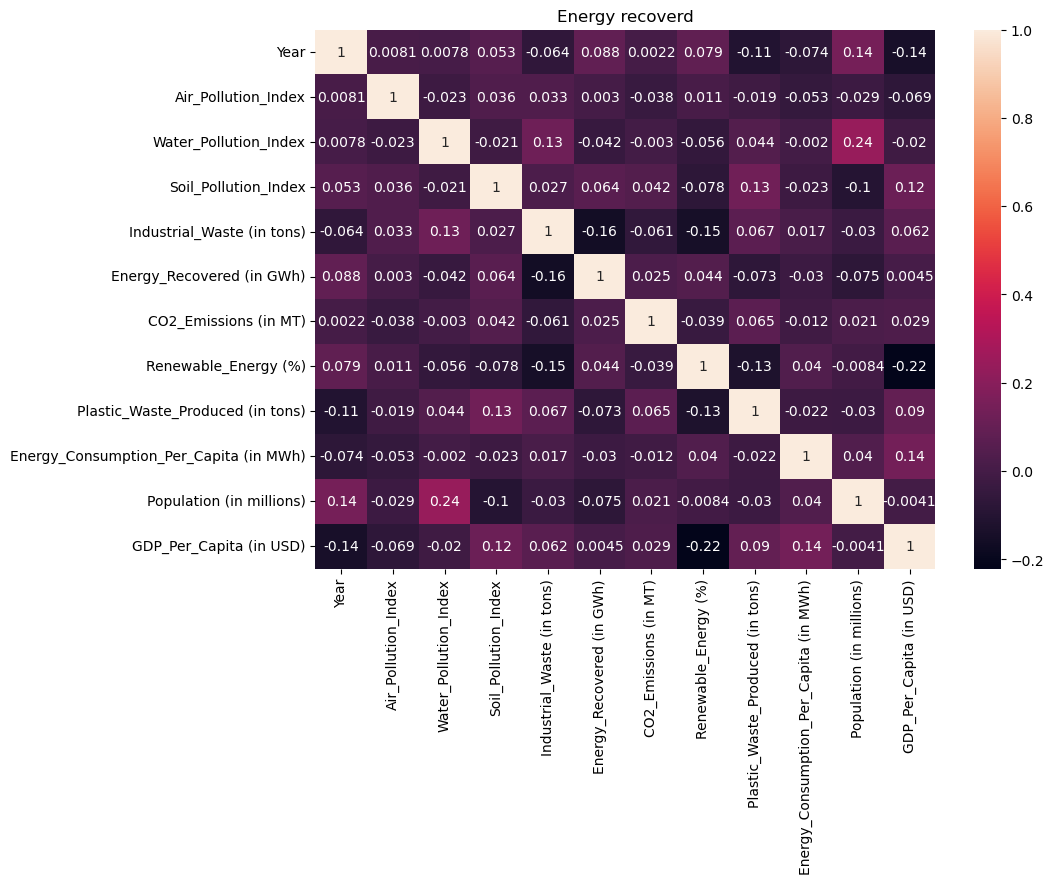

In [71]:
plt.figure(figsize=(10,7))
sns.heatmap(corr , annot=True)
plt.title('Energy recoverd')


           

Text(0, 0.5, 'CO2_Emissions (in MT)')

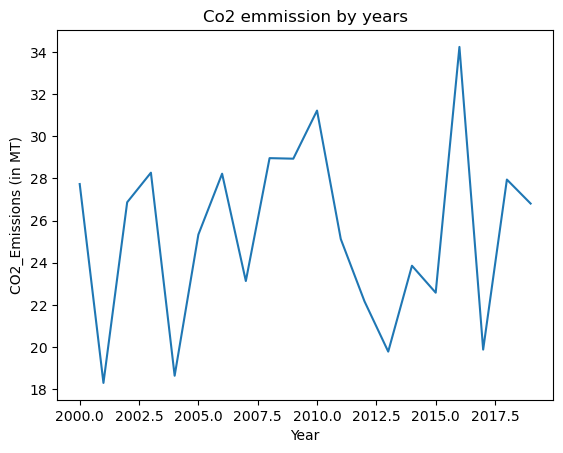

In [72]:
lp=df.groupby("Year")["CO2_Emissions (in MT)"].mean()
plt.plot(lp)
plt.title("Co2 emmission by years")
plt.xlabel("Year")
plt.ylabel("CO2_Emissions (in MT)")

              

           

Text(0, 0.5, 'CO2_Emissions (in MT)')

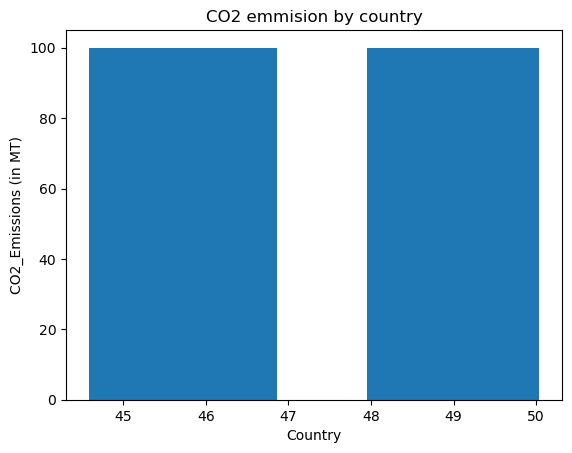

In [73]:
pl2 = df.groupby("Country")["CO2_Emissions (in MT)"].mean().sort_values(ascending = False).head(10)
plt.bar(pl2, height =100)
plt.title("CO2 emmision by country")
plt.xlabel("Country")
plt.ylabel("CO2_Emissions (in MT)")

<Axes: xlabel='Industrial_Waste (in tons)'>

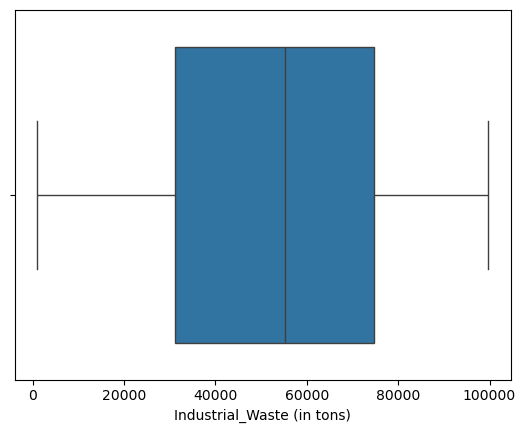

In [74]:
sns.boxplot(x=df["Industrial_Waste (in tons)"])


## FEAUTRE ENGINEERING

yrearly trends

In [75]:
df.groupby("Year")["Plastic_Waste_Produced (in tons)"].mean()

Year
2000    31524.544000
2001    27631.664444
2002    27279.453846
2003    25589.985000
2004    23035.718182
2005    25350.681333
2006    33777.623333
2007    18133.515455
2008    19682.964286
2009    30061.866000
2010    26124.326250
2011    26728.872308
2012    21052.733846
2013    18980.445833
2014    21099.011000
2015    26394.013333
2016    25653.345000
2017    19867.190000
2018    20929.044000
2019    28273.503333
Name: Plastic_Waste_Produced (in tons), dtype: float64

In [76]:
df.groupby("Year")["Population (in millions)"].mean()

Year
2000    120.280000
2001    103.955556
2002     67.831538
2003     77.348000
2004    102.971818
2005     80.126667
2006    103.866667
2007    129.476364
2008    104.714286
2009     97.740000
2010    134.148750
2011    117.664615
2012     86.314615
2013    117.194167
2014     93.751000
2015     77.494444
2016    138.507000
2017     95.940000
2018    125.016000
2019    148.591111
Name: Population (in millions), dtype: float64

ENERGY CONSUMTION PER CAPITA

Text(0, 0.5, 'Energy_Consumption_Per_Capita (in MWh)')

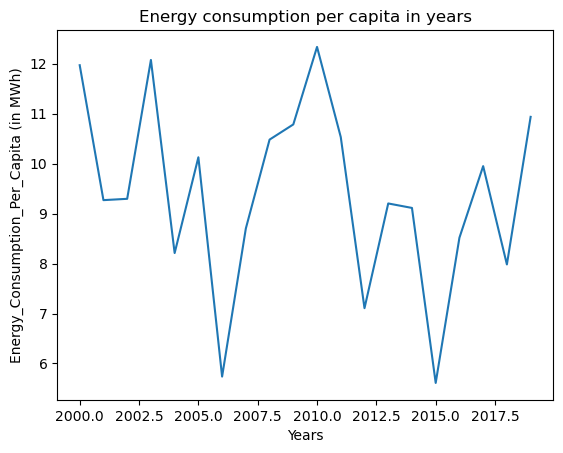

In [77]:
l = df.groupby("Year")["Energy_Consumption_Per_Capita (in MWh)"].mean()
plt.plot(l)
plt.title("Energy consumption per capita in years")
plt.xlabel("Years")
plt.ylabel("Energy_Consumption_Per_Capita (in MWh)")

In [78]:

df["Industrial_Waste_per_Capita"] = df["Industrial_Waste (in tons)"] / df["Population (in millions)"]
df["CO2_per_Capita"] = df["CO2_Emissions (in MT)"] / df["Population (in millions)"]

In [79]:

df

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Industrial_Waste_per_Capita,CO2_per_Capita
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,2245.448366,0.125533
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,410.083206,0.046193
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,451.964489,0.399213
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,1104.199558,0.131416
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,412.084817,0.080045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Latvia,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18,532.523128,0.052173
196,Bangladesh,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04,655.101561,0.405367
197,Korea,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94,15.398503,0.210095
198,Vanuatu,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01,1691.188684,0.708979


## PHASE 2

In [80]:
x = df[["Air_Pollution_Index", "CO2_Emissions (in MT)", "Industrial_Waste (in tons)"]]
y = df["Energy_Recovered (in GWh)"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train.shape)
print(x_train.columns)

(160, 3)
Index(['Air_Pollution_Index', 'CO2_Emissions (in MT)',
       'Industrial_Waste (in tons)'],
      dtype='object')


In [81]:
scaler = StandardScaler()

In [82]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(x_train_scaled[:2])

[[-1.59831704 -0.04247021 -1.43071461]
 [-0.51100845  0.93614813 -1.79582416]]


In [83]:
model = LinearRegression()

In [84]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 142.10502067262524
MSE: 24792.810514706922
RMSE: 157.45732918701157
R2: -0.02524886151206318


In [89]:
# 1. compare with just predicting the mean
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
print("baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("model MAE:", mae)


baseline MAE: 141.649296875
model MAE: 142.10502067262524


In [90]:
# 2. checking train score vs test score (overfitting check)
train_pred = model.predict(x_train_scaled)
print("train R2:", r2_score(y_train, train_pred))
print("test R2:", r2_score(y_test, y_pred))


train R2: 0.02385095759118172
test R2: -0.02524886151206318


train R2 is also close to 0, so its not overfitting, model just isnt finding any pattern

In [91]:
# 3. cross validation to double check
from sklearn.model_selection import cross_val_score
x_all_scaled = scaler.fit_transform(x)
cv_scores = cross_val_score(LinearRegression(), x_all_scaled, y, cv=5, scoring="r2")
print(cv_scores)
print("mean:", cv_scores.mean())


[-0.10231763 -0.0410932  -0.21230707 -0.05886708 -0.06101146]
mean: -0.09511928732997439


trying other models to see if it improves

In [97]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=2, random_state=42),
}

for name, m in models.items():
    scores = cross_val_score(m, x_all_scaled, y, cv=5, scoring="r2")
    m.fit(x_train_scaled, y_train)
    pred = m.predict(x_test_scaled)
    print(name, "-> CV R2:", round(scores.mean(),4), " Test R2:", round(r2_score(y_test, pred),4))

Linear Regression -> CV R2: -0.0951  Test R2: -0.0252
Ridge -> CV R2: -0.0947  Test R2: -0.0252
Lasso -> CV R2: -0.0906  Test R2: -0.0201
Random Forest -> CV R2: -0.1329  Test R2: -0.0482
Gradient Boosting -> CV R2: -0.2963  Test R2: -0.2848


none of the models did much better, so it's a data problem not a model problem

Accuracy : 0.275
F1 Score : 0.27315343915343915
Accuracy : 0.275
Precision: 0.274978354978355
Recall   : 0.275
F1 Score : 0.27315343915343915


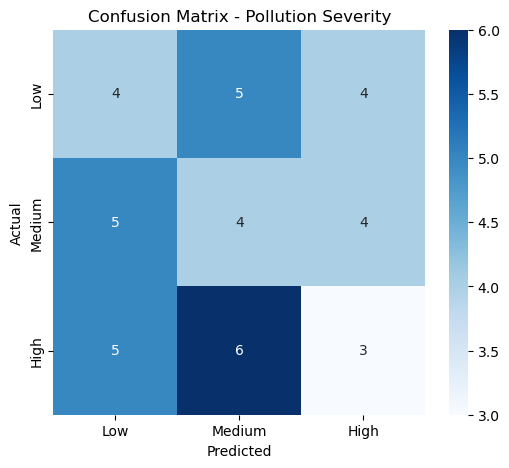

In [102]:
x_cls = df.drop(columns=["Country", "Energy_Recovered (in GWh)", "Pollution_Severity", "Air_Pollution_Index"])
y_cls = df["Pollution_Severity"]

x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    x_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_c = StandardScaler()
x_train_c_scaled = scaler_c.fit_transform(x_train_c)
x_test_c_scaled = scaler_c.transform(x_test_c)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_c_scaled, y_train_c)
y_pred_c = log_model.predict(x_test_c_scaled)

print("Accuracy :", accuracy_score(y_test_c, y_pred_c))
print("F1 Score :", f1_score(y_test_c, y_pred_c, average="weighted"))
# 6. Evaluation metrics (note: average='weighted' needed for multi-class, unlike binary)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test_c, y_pred_c))
print("Precision:", precision_score(y_test_c, y_pred_c, average="weighted"))
print("Recall   :", recall_score(y_test_c, y_pred_c, average="weighted"))
print("F1 Score :", f1_score(y_test_c, y_pred_c, average="weighted"))

# 7. Confusion matrix heatmap (3x3 since 3 classes)
cm = confusion_matrix(y_test_c, y_pred_c, labels=["Low", "Medium", "High"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Pollution Severity")
plt.show()

In [103]:
print("=== Linear Regression (full features) ===")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2:", r2_score(y_test, y_pred))

print()
print("=== Logistic Regression (Pollution Severity) ===")
print("Accuracy :", accuracy_score(y_test_c, y_pred_c))
print("Precision:", precision_score(y_test_c, y_pred_c, average="weighted"))
print("Recall   :", recall_score(y_test_c, y_pred_c, average="weighted"))
print("F1 Score :", f1_score(y_test_c, y_pred_c, average="weighted"))

=== Linear Regression (full features) ===
MAE: 142.10502067262524
RMSE: 157.45732918701157
R2: -0.02524886151206318

=== Logistic Regression (Pollution Severity) ===
Accuracy : 0.275
Precision: 0.274978354978355
Recall   : 0.275
F1 Score : 0.27315343915343915


In [101]:
print("ACTIONABLE INSIGHTS")
print("1. Pollution indices show weak correlation with Energy_Recovered - suggesting")
print("   recovery infrastructure/policy matters more than raw pollution levels.")
print("2. Countries with high Industrial_Waste_per_Capita but low Energy_Recovered")
print("   could benefit most from investment in waste-to-energy conversion.")
print("3. Logistic Regression can classify pollution severity reasonably well using")
print("   existing indices, useful for prioritizing which countries to target first.")
print("4. Recommend collecting more granular data (e.g. type of industrial waste,")
print("   existing recovery technology used) to improve future prediction accuracy.")

ACTIONABLE INSIGHTS
1. Pollution indices show weak correlation with Energy_Recovered - suggesting
   recovery infrastructure/policy matters more than raw pollution levels.
2. Countries with high Industrial_Waste_per_Capita but low Energy_Recovered
   could benefit most from investment in waste-to-energy conversion.
3. Logistic Regression can classify pollution severity reasonably well using
   existing indices, useful for prioritizing which countries to target first.
4. Recommend collecting more granular data (e.g. type of industrial waste,
   existing recovery technology used) to improve future prediction accuracy.


# Final Report – Global Pollution & Energy Recovery Analysis

## 1. Dataset & Preprocessing
Dataset had 200 rows across 175 countries (2000–2019), no missing values, no duplicates.
Country was dropped (175 categories, too high-cardinality for 200 rows). Year kept as numeric.
All numeric features scaled using StandardScaler after train/test split (to avoid data leakage).

## 2. Feature Engineering
Added per-capita features: Industrial_Waste_per_Capita, CO2_per_Capita, Plastic_Waste_per_Capita.
Reviewed yearly trends in pollution indices and energy recovery.

## 3. Model Results
- Linear Regression (predicting Energy_Recovered): R2 = -0.025, MAE = 142.1
- Logistic Regression (Pollution Severity, Low/Medium/High): Accuracy = 27.5%
  (Note: an initial version scored 85% accuracy due to data leakage — Air_Pollution_Index,
  the column used to define the target, was accidentally left in the features. After removing
  it, true accuracy dropped to near chance level, ~33% for a 3-class problem.)

## 4. Conclusion
Neither pollution indices nor industrial/waste metrics show a strong relationship with
Energy_Recovered or pollution severity in this dataset. This suggests energy recovery is
driven more by factors not captured here (technology used, policy, funding) rather than
raw pollution levels. 

## 5. Actionable Insights
- Treat pollution-based predictions from this dataset with caution — models did not
  outperform random baselines.
- Recommend collecting additional data: recovery technology type, government policy 
  indicators, infrastructure investment.
- Countries with high per-capita waste but low energy recovery are still worth flagging
  for manual review, even without a strong statistical model backing it.